Step 1 — Load the cleaned dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Task_8_Cleaned_Retail_Sales.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (120, 17)

Columns:
['order_id', 'order_date', 'customer_id', 'customer_name', 'city', 'category', 'product', 'quantity', 'unit_price', 'discount_pct', 'payment_method', 'sales_channel', 'status', 'gross_sales', 'discount_amount', 'net_sales', 'month']


,order_id,order_date,customer_id,customer_name,city,category,product,quantity,unit_price,discount_pct,payment_method,sales_channel,status,gross_sales,discount_amount,net_sales,month
0,O0001,2026-02-05,C011,Vikas Tiwari,Ujjain,electronics,Wireless Mouse,6.0,900.0,0,cash,online,completed,5400.0,0.0,5400.0,2026-02
1,O0002,2026-04-25,C004,Neha Singh,Jabalpur,electronics,Headphones,1.0,1400.0,15,cod,offline,completed,1400.0,210.0,1190.0,2026-04
2,O0003,2026-06-04,C006,Sneha Gupta,Bhopal,electronics,Wireless Mouse,1.0,700.0,20,upi,offline,pending,700.0,140.0,560.0,2026-06
3,O0004,2026-02-28,C005,rohit patel,Ujjain,grocery,Cooking Oil,1.0,160.0,0,upi,online,cancelled,160.0,0.0,160.0,2026-02
4,O0005,2026-12-06,C003,AMIT KHAN,Rewa,grocery,Rice Bag,5.0,950.0,5,cash,online,cancelled,4750.0,237.5,4512.5,2026-12


Step 2 — Verify the data

In [3]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         120 non-null    object 
 1   order_date       120 non-null    object 
 2   customer_id      120 non-null    object 
 3   customer_name    120 non-null    object 
 4   city             120 non-null    object 
 5   category         120 non-null    object 
 6   product          120 non-null    object 
 7   quantity         120 non-null    float64
 8   unit_price       120 non-null    float64
 9   discount_pct     120 non-null    int64  
 10  payment_method   120 non-null    object 
 11  sales_channel    120 non-null    object 
 12  status           120 non-null    object 
 13  gross_sales      120 non-null    float64
 14  discount_amount  120 non-null    float64
 15  net_sales        120 non-null    float64
 16  month            120 non-null    object 
dtypes: float64(5), i

In [ ]:
#Step 3 — Our first comparison

In [4]:
category_comparison = df.groupby('category').agg(
    Total_Net_Sales=('net_sales', 'sum'),
    Total_Orders=('order_id', 'count'),
    Total_Quantity=('quantity', 'sum')
).reset_index()

category_comparison['Avg_Sales_per_Order'] = (
    category_comparison['Total_Net_Sales'] /
    category_comparison['Total_Orders']
)

category_comparison

,category,Total_Net_Sales,Total_Orders,Total_Quantity,Avg_Sales_per_Order
0,clothing,105225.0,28,93.0,3758.035714
1,electronics,84400.0,29,100.0,2910.344828
2,grocery,55539.5,36,119.0,1542.763889
3,home,78405.0,27,104.0,2903.888889


In [ ]:
#Step 4 — Calculate each category's share

In [5]:
category_comparison['Sales_Share_%'] = (
    category_comparison['Total_Net_Sales'] /
    category_comparison['Total_Net_Sales'].sum()
) * 100

category_comparison['Order_Share_%'] = (
    category_comparison['Total_Orders'] /
    category_comparison['Total_Orders'].sum()
) * 100

category_comparison.round(2)

,category,Total_Net_Sales,Total_Orders,Total_Quantity,Avg_Sales_per_Order,Sales_Share_%,Order_Share_%
0,clothing,105225.0,28,93.0,3758.04,32.52,23.33
1,electronics,84400.0,29,100.0,2910.34,26.08,24.17
2,grocery,55539.5,36,119.0,1542.76,17.16,30.00
3,home,78405.0,27,104.0,2903.89,24.23,22.50


In [7]:
#Step 5 — Interpret Sales Share vs Order Share
# Key insight

#Clothing:
#23.33% of orders generate 32.52% of sales. Its sales share is much higher than its order share, indicating that clothing orders have relatively higher value.

#Grocery:
#30% of orders generate only 17.16% of sales. This is the opposite pattern—many orders, but comparatively lower sales per order.

#This is more meaningful than simply saying “Clothing is the top category.” We're now explaining why the categories differ, which is the objective of Task 10

In [6]:
#tep 6 — Create the first Task 10 chart

#Let's visually compare Sales Share vs Order Share.

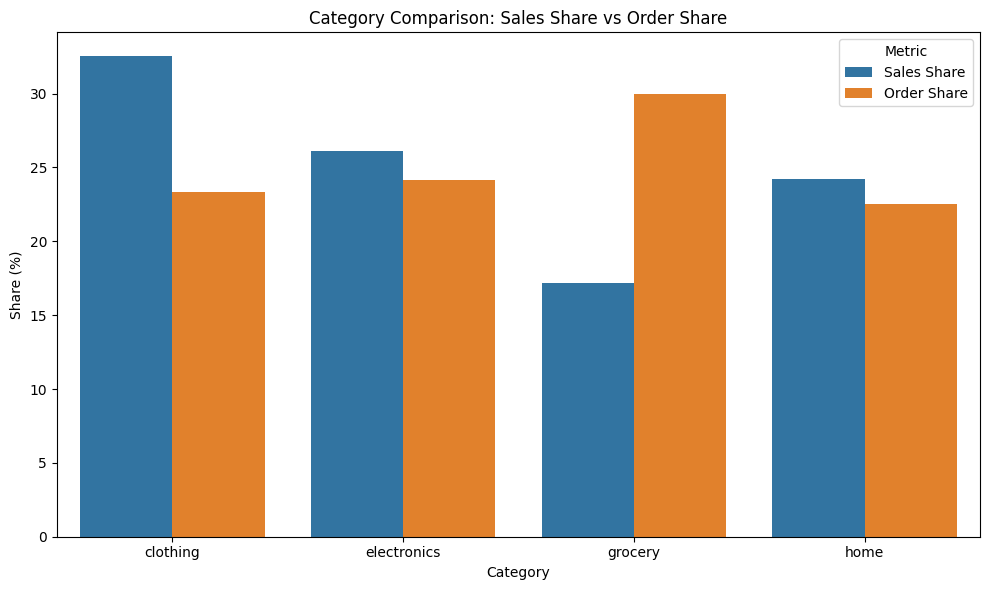

In [8]:
share_comparison = category_comparison[
    ['category', 'Sales_Share_%', 'Order_Share_%']
].melt(
    id_vars='category',
    var_name='Metric',
    value_name='Share'
)

share_comparison['Metric'] = share_comparison['Metric'].replace({
    'Sales_Share_%': 'Sales Share',
    'Order_Share_%': 'Order Share'
})

plt.figure(figsize=(10, 6))

sns.barplot(
    data=share_comparison,
    x='category',
    y='Share',
    hue='Metric'
)

plt.title('Category Comparison: Sales Share vs Order Share')
plt.xlabel('Category')
plt.ylabel('Share (%)')
plt.legend(title='Metric')
plt.tight_layout()

plt.show()

In [ ]:
#Step 7 — Channel comparison

In [9]:
channel_comparison = df.groupby('sales_channel').agg(
    Total_Net_Sales=('net_sales', 'sum'),
    Total_Orders=('order_id', 'count'),
    Total_Quantity=('quantity', 'sum')
).reset_index()

channel_comparison['Avg_Sales_per_Order'] = (
    channel_comparison['Total_Net_Sales'] /
    channel_comparison['Total_Orders']
)

channel_comparison['Sales_Share_%'] = (
    channel_comparison['Total_Net_Sales'] /
    channel_comparison['Total_Net_Sales'].sum()
) * 100

channel_comparison['Order_Share_%'] = (
    channel_comparison['Total_Orders'] /
    channel_comparison['Total_Orders'].sum()
) * 100

channel_comparison.round(2)

,sales_channel,Total_Net_Sales,Total_Orders,Total_Quantity,Avg_Sales_per_Order,Sales_Share_%,Order_Share_%
0,offline,117767.0,46,144.0,2560.15,36.4,38.33
1,online,205802.5,74,272.0,2781.11,63.6,61.67


🔎 Comparative insight

Online

Generates 63.6% of total net sales
Accounts for 61.67% of orders
Average sales/order = ₹2,781.11
Sales share is 1.93 percentage points higher than order share.

Offline

Generates 36.4% of sales
Accounts for 38.33% of orders
Average sales/order = ₹2,560.15
Order share is 1.93 percentage points higher than sales share.

So the difference between the channels is relatively consistent: Online has a slightly higher sales contribution relative to its order contribution, while Offline has the reverse pattern.

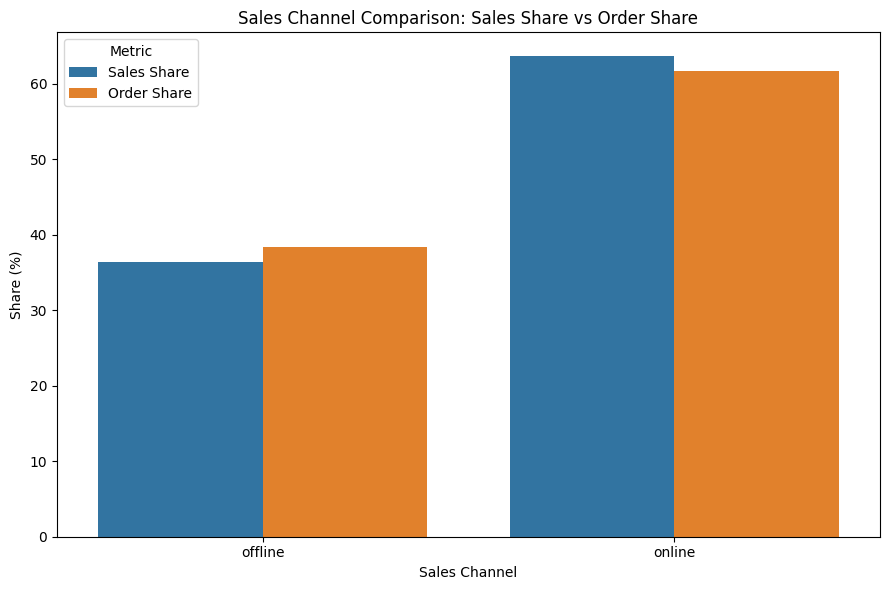

In [10]:
#Step 8 — Create Comparison 2 chart
channel_share = channel_comparison[
    ['sales_channel', 'Sales_Share_%', 'Order_Share_%']
].melt(
    id_vars='sales_channel',
    var_name='Metric',
    value_name='Share'
)

channel_share['Metric'] = channel_share['Metric'].replace({
    'Sales_Share_%': 'Sales Share',
    'Order_Share_%': 'Order Share'
})

plt.figure(figsize=(9, 6))

sns.barplot(
    data=channel_share,
    x='sales_channel',
    y='Share',
    hue='Metric'
)

plt.title('Sales Channel Comparison: Sales Share vs Order Share')
plt.xlabel('Sales Channel')
plt.ylabel('Share (%)')
plt.legend(title='Metric')
plt.tight_layout()

plt.show()

In [11]:
#Step 9 — Order Status comparison
status_comparison = df.groupby('status').agg(
    Total_Net_Sales=('net_sales', 'sum'),
    Total_Orders=('order_id', 'count'),
    Total_Quantity=('quantity', 'sum')
).reset_index()

status_comparison['Avg_Sales_per_Order'] = (
    status_comparison['Total_Net_Sales'] /
    status_comparison['Total_Orders']
)

status_comparison['Sales_Share_%'] = (
    status_comparison['Total_Net_Sales'] /
    status_comparison['Total_Net_Sales'].sum()
) * 100

status_comparison['Order_Share_%'] = (
    status_comparison['Total_Orders'] /
    status_comparison['Total_Orders'].sum()
) * 100

status_comparison.round(2)

,status,Total_Net_Sales,Total_Orders,Total_Quantity,Avg_Sales_per_Order,Sales_Share_%,Order_Share_%
0,cancelled,100625.0,39,129.0,2580.13,31.10,32.5
1,completed,112678.5,45,156.0,2503.97,34.82,37.5
2,pending,110266.0,36,131.0,3062.94,34.08,30.0


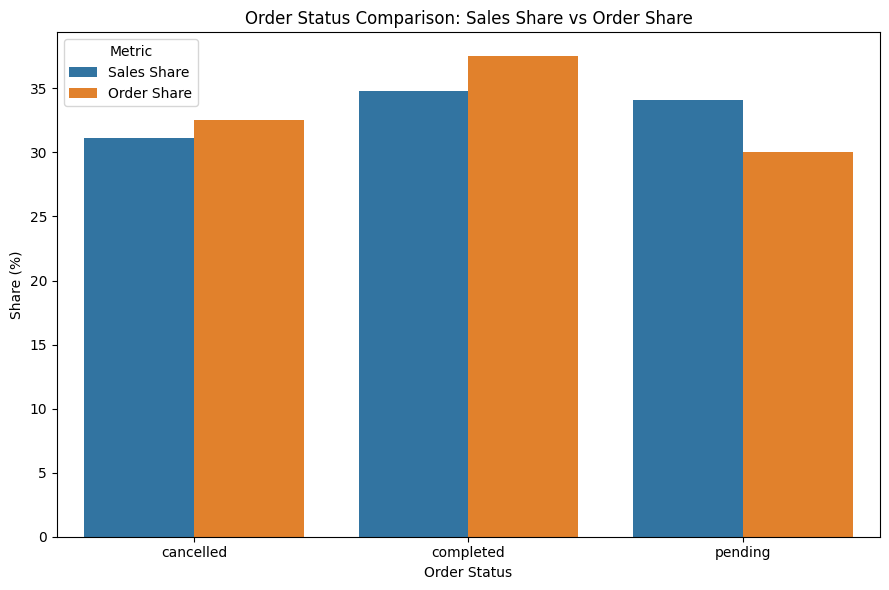

In [12]:
#Step 10 — Create the Order Status comparison chart
status_share = status_comparison[
    ['status', 'Sales_Share_%', 'Order_Share_%']
].melt(
    id_vars='status',
    var_name='Metric',
    value_name='Share'
)

status_share['Metric'] = status_share['Metric'].replace({
    'Sales_Share_%': 'Sales Share',
    'Order_Share_%': 'Order Share'
})

plt.figure(figsize=(9, 6))

sns.barplot(
    data=status_share,
    x='status',
    y='Share',
    hue='Metric'
)

plt.title('Order Status Comparison: Sales Share vs Order Share')
plt.xlabel('Order Status')
plt.ylabel('Share (%)')
plt.legend(title='Metric')
plt.tight_layout()

plt.show()

In [13]:
#Step 11 — Category × Sales Channel
category_channel = df.groupby(
    ['category', 'sales_channel']
).agg(
    Total_Net_Sales=('net_sales', 'sum'),
    Total_Orders=('order_id', 'count'),
    Total_Quantity=('quantity', 'sum')
).reset_index()

category_channel['Avg_Sales_per_Order'] = (
    category_channel['Total_Net_Sales'] /
    category_channel['Total_Orders']
)

category_channel.round(2)

,category,sales_channel,Total_Net_Sales,Total_Orders,Total_Quantity,Avg_Sales_per_Order
0,clothing,offline,40035.0,10,33.0,4003.50
1,clothing,online,65190.0,18,60.0,3621.67
2,electronics,offline,20172.5,11,24.0,1833.86
3,electronics,online,64227.5,18,76.0,3568.19
4,grocery,offline,19449.5,12,37.0,1620.79
5,grocery,online,36090.0,24,82.0,1503.75
6,home,offline,38110.0,13,50.0,2931.54
7,home,online,40295.0,14,54.0,2878.21


In [14]:
category_channel_pivot = category_channel.pivot(
    index='category',
    columns='sales_channel',
    values='Total_Net_Sales'
).fillna(0)

category_channel_pivot

sales_channel,offline,online
category,,
clothing,40035.0,65190.0
electronics,20172.5,64227.5
grocery,19449.5,36090.0
home,38110.0,40295.0


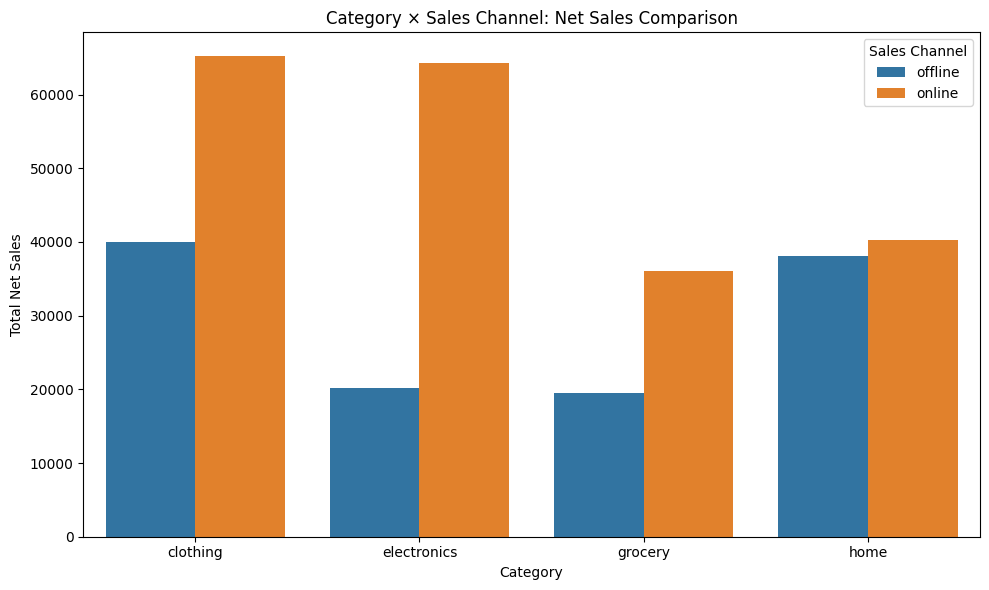

In [15]:
#Step 12 — Create the cross-segment chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_channel,
    x='category',
    y='Total_Net_Sales',
    hue='sales_channel'
)

plt.title('Category × Sales Channel: Net Sales Comparison')
plt.xlabel('Category')
plt.ylabel('Total Net Sales')
plt.legend(title='Sales Channel')
plt.tight_layout()

plt.show()

What this chart helps us verify

We're looking for whether the category pattern remains similar across online and offline channels.

For example:

If Clothing is the strongest category overall, is it also strong in both channels?

And:

If Grocery is lower overall, is it lower in both channels or is one channel responsible?

This is the Simpson's paradox check required by Task 10. The brief specifically tells us to check for a reversing sub-trend before reaching a conclusion.

In [16]:
#Step 13 — Calculate category contribution
category_comparison['Sales_Contribution_%'] = (
    category_comparison['Total_Net_Sales'] /
    category_comparison['Total_Net_Sales'].sum()
) * 100

category_comparison['Sales_per_Order_Index'] = (
    category_comparison['Avg_Sales_per_Order'] /
    category_comparison['Avg_Sales_per_Order'].mean()
) * 100

category_comparison[
    [
        'category',
        'Total_Net_Sales',
        'Total_Orders',
        'Avg_Sales_per_Order',
        'Sales_Contribution_%',
        'Sales_per_Order_Index'
    ]
].round(2)

,category,Total_Net_Sales,Total_Orders,Avg_Sales_per_Order,Sales_Contribution_%,Sales_per_Order_Index
0,clothing,105225.0,28,3758.04,32.52,135.24
1,electronics,84400.0,29,2910.34,26.08,104.74
2,grocery,55539.5,36,1542.76,17.16,55.52
3,home,78405.0,27,2903.89,24.23,104.50


Why we're doing this

This separates two different effects:

1. Volume effect → How many orders does the category have?

2. Value effect → How much sales does each order generate?

For example, from our earlier results:

Grocery: highest order count but lowest average sales/order.
Clothing: fewer orders than Grocery but substantially higher average sales/order.

That tells us why raw order count alone doesn't explain the sales result.